In [1]:
import sys
from pathlib import Path

# Make `src` importable regardless of the kernel's working directory
# (VSCode starts the kernel at the workspace root, not notebooks/).
repo_root = Path.cwd()
while not (repo_root / "src").is_dir() and repo_root != repo_root.parent:
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.data_loader import load_prices

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

In [2]:
prices = load_prices()
print(prices.shape)
prices.tail()

(6632, 7)


Ticker,AGG,BIL,DBC,EFA,GLD,SPY,VNQ
Date,,,,,,,
2026-05-11,98.919998,91.480003,31.059999,103.739998,434.649994,739.299988,96.690002
2026-05-12,98.629997,91.489998,31.690001,103.139999,432.929993,738.179993,96.690002
2026-05-13,98.669998,91.489998,31.370001,103.830002,430.500000,742.309998,95.889999
2026-05-14,98.639999,91.510002,31.150000,103.459999,427.209991,748.169983,95.320000
2026-05-15,98.019997,91.529999,31.190001,101.720001,417.290009,739.169983,93.910004


In [3]:
spy_price = prices["SPY"]
spy_sma200 = spy_price.rolling(window=200).mean()

print("Price head:")
print(spy_price.head(3))
print("\nSMA head (will be NaN until we have 200 days):")
print(spy_sma200.head(3))
print("\nSMA tail (recent values, should be valid):")
print(spy_sma200.tail(3))

Price head:
Date
2000-01-03    91.367500
2000-01-04    87.794487
2000-01-05    87.951546
Name: SPY, dtype: float64

SMA head (will be NaN until we have 200 days):
Date
2000-01-03   NaN
2000-01-04   NaN
2000-01-05   NaN
Name: SPY, dtype: float64

SMA tail (recent values, should be valid):
Date
2026-05-13    672.193680
2026-05-14    672.784945
2026-05-15    673.335177
Name: SPY, dtype: float64


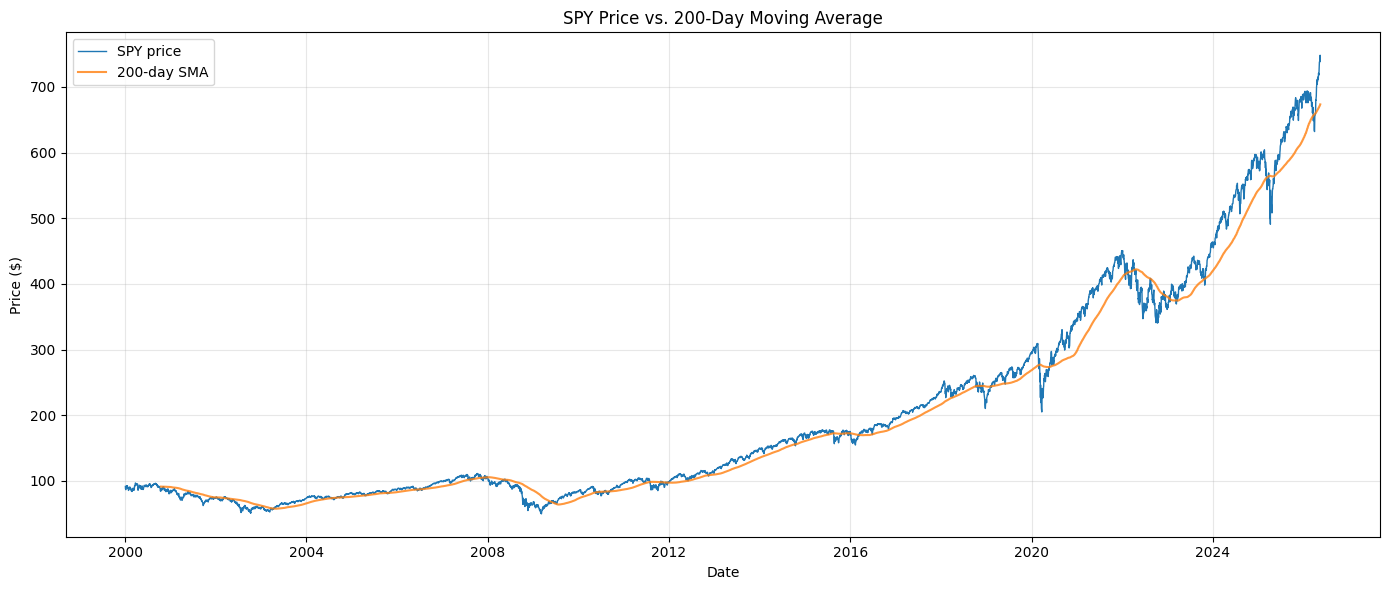

In [4]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(spy_price.index, spy_price, label="SPY price", linewidth=1)
ax.plot(spy_sma200.index, spy_sma200, label="200-day SMA", linewidth=1.5, alpha=0.8)

ax.set_title("SPY Price vs. 200-Day Moving Average")
ax.set_xlabel("Date")
ax.set_ylabel("Price ($)")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [5]:
spy_signal = (spy_price > spy_sma200)
print("Signal tail:")
print(spy_signal.tail(5))
print(f"\nSignal type: {spy_signal.dtype}")
print(f"% of days 'on' (overall): {spy_signal.mean():.1%}")

Signal tail:
Date
2026-05-11    True
2026-05-12    True
2026-05-13    True
2026-05-14    True
2026-05-15    True
Name: SPY, dtype: bool

Signal type: bool
% of days 'on' (overall): 71.3%


In [6]:
print(f"Total days: {len(spy_signal)}")
print(f"Days True: {spy_signal.sum()}")
print(f"Days False: {(~spy_signal).sum()}")
print(f"First non-NaN SMA date: {spy_sma200.first_valid_index().date()}")

Total days: 6632
Days True: 4731
Days False: 1901
First non-NaN SMA date: 2000-10-16


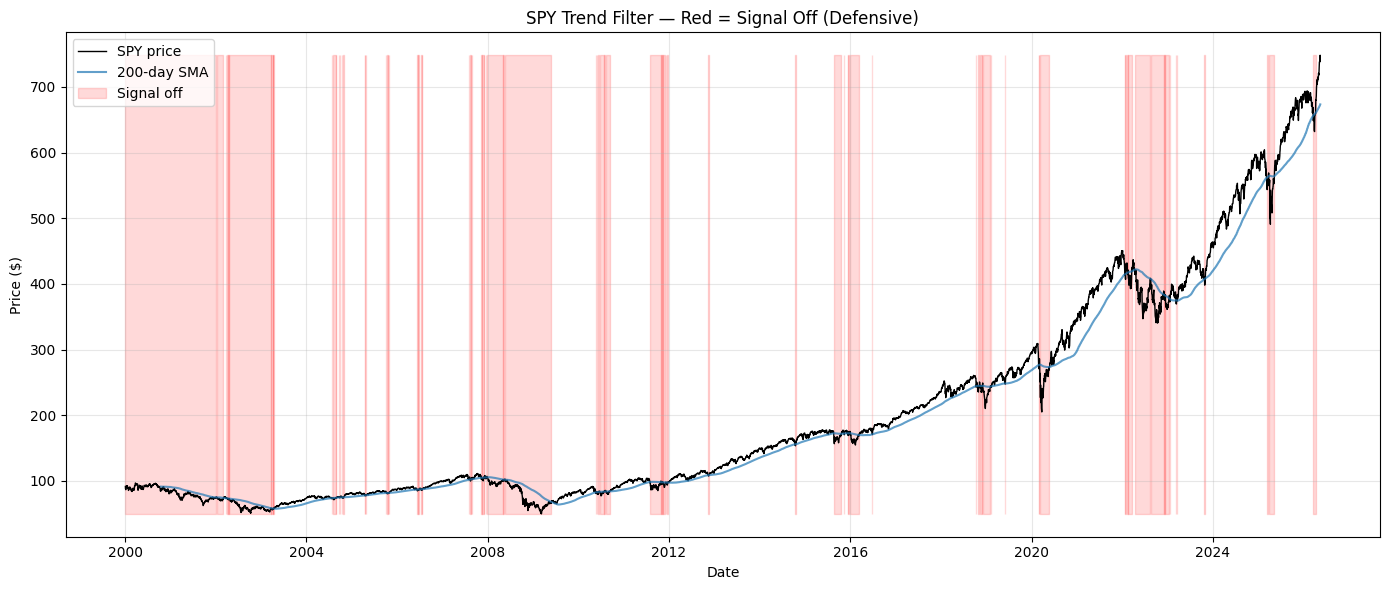

In [7]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(spy_price.index, spy_price, label="SPY price", linewidth=1, color="black")
ax.plot(spy_sma200.index, spy_sma200, label="200-day SMA", linewidth=1.5, alpha=0.7, color="C0")

# Shade the "off" periods in light red
ax.fill_between(
    spy_signal.index,
    spy_price.min(),
    spy_price.max(),
    where=~spy_signal,
    alpha=0.15,
    color="red",
    label="Signal off",
)

ax.set_title("SPY Trend Filter — Red = Signal Off (Defensive)")
ax.set_xlabel("Date")
ax.set_ylabel("Price ($)")
ax.legend(loc="upper left")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
sma200 = prices.rolling(window=200).mean()

print("SMA200 shape:", sma200.shape)
print("\nSMA200 tail:")
print(sma200.tail(3))

SMA200 shape: (6632, 7)

SMA200 tail:
Ticker            AGG        BIL        DBC        EFA        GLD         SPY        VNQ
Date                                                                                    
2026-05-13  98.356887  90.201065  24.114742  95.951559  396.26605  672.193680  90.001398
2026-05-14  98.371801  90.214519  24.160736  96.031239  396.87085  672.784945  90.032653
2026-05-15  98.384969  90.228025  24.207172  96.105362  397.45250  673.335177  90.063172


In [9]:
signal_200d = (prices > sma200)

print("Signal shape:", signal_200d.shape)
print("\nMost recent signal values:")
print(signal_200d.tail(3))

Signal shape: (6632, 7)

Most recent signal values:
Ticker        AGG   BIL   DBC   EFA   GLD   SPY   VNQ
Date                                                 
2026-05-13   True  True  True  True  True  True  True
2026-05-14   True  True  True  True  True  True  True
2026-05-15  False  True  True  True  True  True  True


In [10]:
on_rate = signal_200d.mean()
print("Percent of days each ETF was 'on':")
print(on_rate.sort_values(ascending=False).to_string(float_format='{:.1%}'.format))

Percent of days each ETF was 'on':
Ticker
SPY   71.3%
EFA   64.2%
AGG   63.8%
VNQ   54.4%
GLD   54.3%
BIL   43.2%
DBC   40.7%


In [11]:
bil_signal = signal_200d["BIL"]
bil_valid = bil_signal.loc[prices["BIL"].first_valid_index():]
print(f"BIL signal 'on' rate, full sample:        {bil_signal.mean():.1%}")
print(f"BIL signal 'on' rate, from inception:     {bil_valid.mean():.1%}")
print(f"BIL signal 'on' rate, post-2016 (rates rose): {bil_valid.loc['2016':].mean():.1%}")

BIL signal 'on' rate, full sample:        43.2%
BIL signal 'on' rate, from inception:     60.0%
BIL signal 'on' rate, post-2016 (rates rose): 84.2%


In [12]:
sma_fast = prices.rolling(window=10).mean()
sma_slow = prices.rolling(window=30).mean()

signal_crossover = (sma_fast > sma_slow)

print("Signal shape:", signal_crossover.shape)
print("\nMost recent signal values:")
print(signal_crossover.tail(3))

# Compare turnover
print("\nPercent of days 'on' — both signals:")
comparison = pd.DataFrame({
    "200-day SMA":      signal_200d.mean(),
    "10/30 crossover":  signal_crossover.mean(),
})
print(comparison)

Signal shape: (6632, 7)

Most recent signal values:
Ticker        AGG   BIL   DBC   EFA    GLD   SPY   VNQ
Date                                                  
2026-05-13  False  True  True  True  False  True  True
2026-05-14  False  True  True  True  False  True  True
2026-05-15  False  True  True  True  False  True  True

Percent of days 'on' — both signals:
        200-day SMA  10/30 crossover
Ticker                              
AGG        0.637666         0.548703
BIL        0.431996         0.468185
DBC        0.406815         0.423100
EFA        0.642189         0.584590
GLD        0.543275         0.454614
SPY        0.713359         0.643999
VNQ        0.544331         0.499397
